In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


/tmp/ipykernel_6940/110551032.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='AgeGroup', palette='viridis')


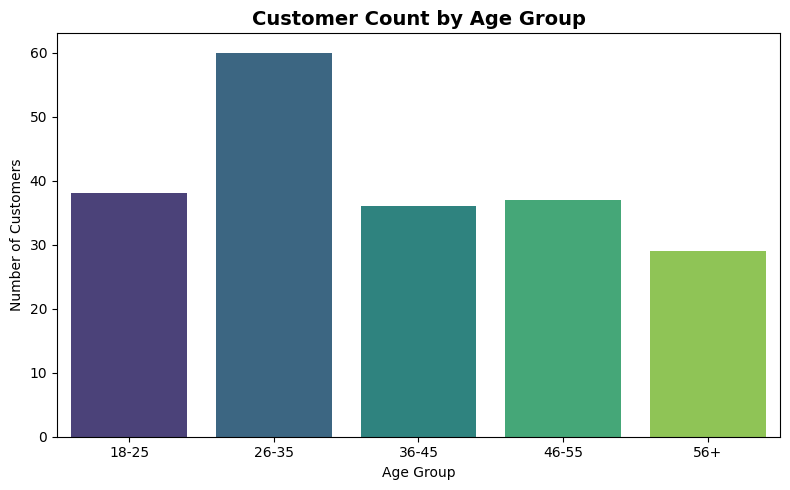

In [10]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 25, 35, 45, 55, 70],
                          labels=['18-25', '26-35', '36-45', '46-55', '56+'])

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='AgeGroup', palette='viridis')
plt.title('Customer Count by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

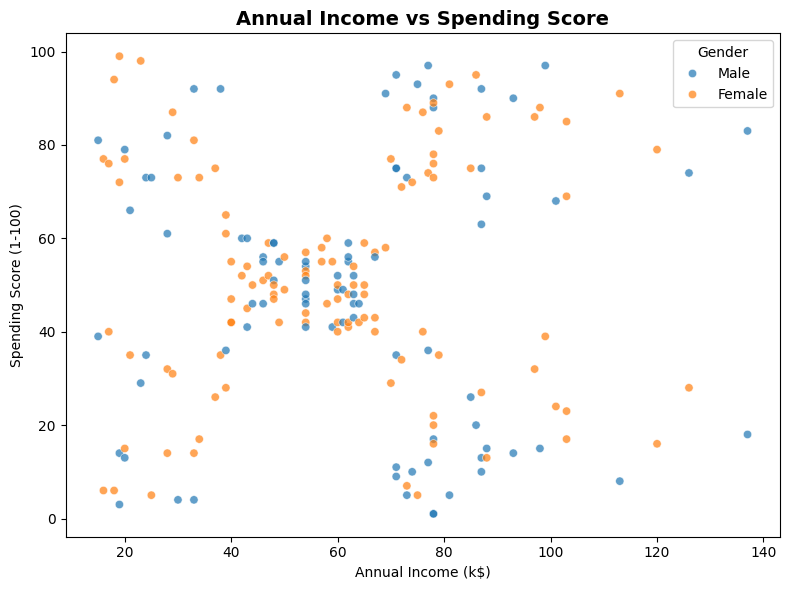

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', alpha=0.7)
plt.title('Annual Income vs Spending Score', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6940/2502945610.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='IncomeSegment', palette='coolwarm')


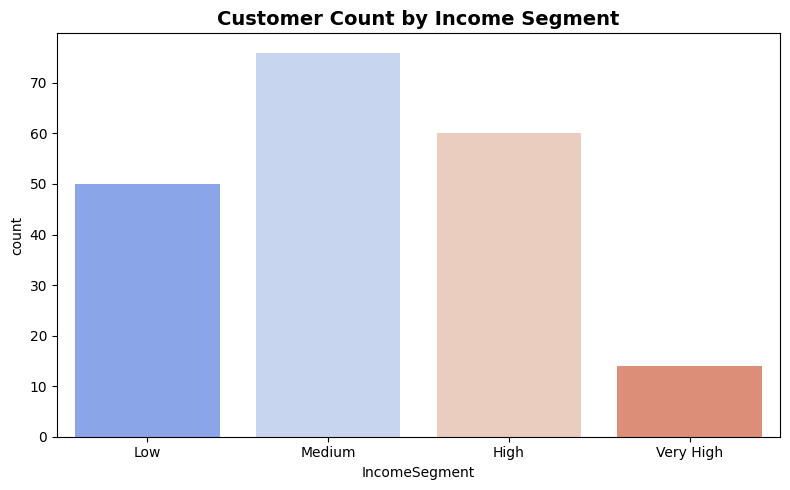

In [12]:
df['IncomeSegment'] = pd.cut(df['Annual Income (k$)'], bins=[0, 40, 70, 100, 150],
                               labels=['Low', 'Medium', 'High', 'Very High'])

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='IncomeSegment', palette='coolwarm')
plt.title('Customer Count by Income Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
df['ValueSegment'] = 'Other'
df.loc[(df['Annual Income (k$)'] >= 70) & (df['Spending Score (1-100)'] >= 60), 'ValueSegment'] = 'High Value'
df.loc[(df['Annual Income (k$)'] >= 70) & (df['Spending Score (1-100)'] < 40), 'ValueSegment'] = 'High Income, Low Spender'
df.loc[(df['Annual Income (k$)'] < 40) & (df['Spending Score (1-100)'] >= 60), 'ValueSegment'] = 'Low Income, High Spender'

df['ValueSegment'].value_counts()

,count
ValueSegment,
Other,102
High Value,38
"High Income, Low Spender",37
"Low Income, High Spender",23


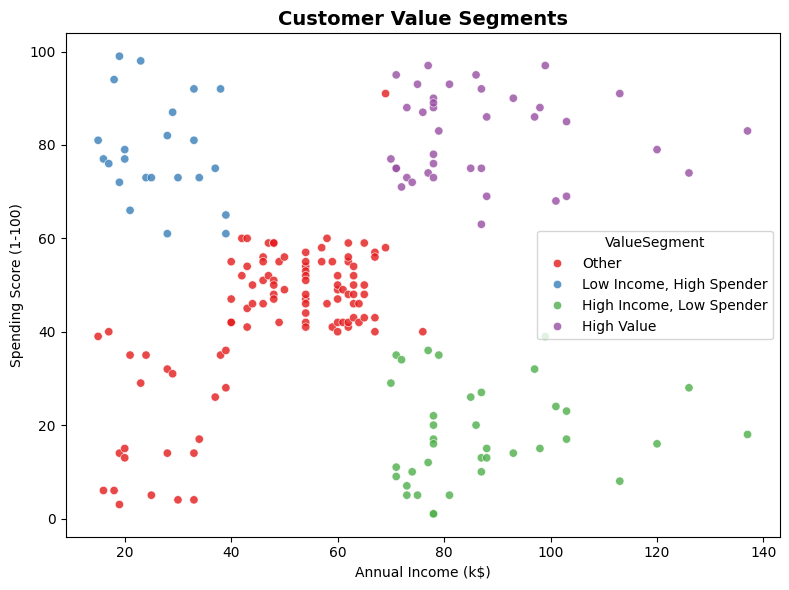

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='ValueSegment', palette='Set1', alpha=0.8)
plt.title('Customer Value Segments', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.show()

In [15]:
high_value = df[df['ValueSegment'] == 'High Value']
print('Number of high-value customers:', len(high_value))
print('Average age:', round(high_value['Age'].mean(), 1))
print('Gender split:')
print(high_value['Gender'].value_counts())

Number of high-value customers: 38
Average age: 32.5
Gender split:
Gender
Female    21
Male      17
Name: count, dtype: int64


/tmp/ipykernel_6940/3276037905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='AgeGroup', ax=axes[0,0], palette='viridis')
/tmp/ipykernel_6940/3276037905.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Spending Score (1-100)', ax=axes[0,1], palette='Set2')
/tmp/ipykernel_6940/3276037905.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ValueSegment', ax=axes[1,0], palette='Set1')


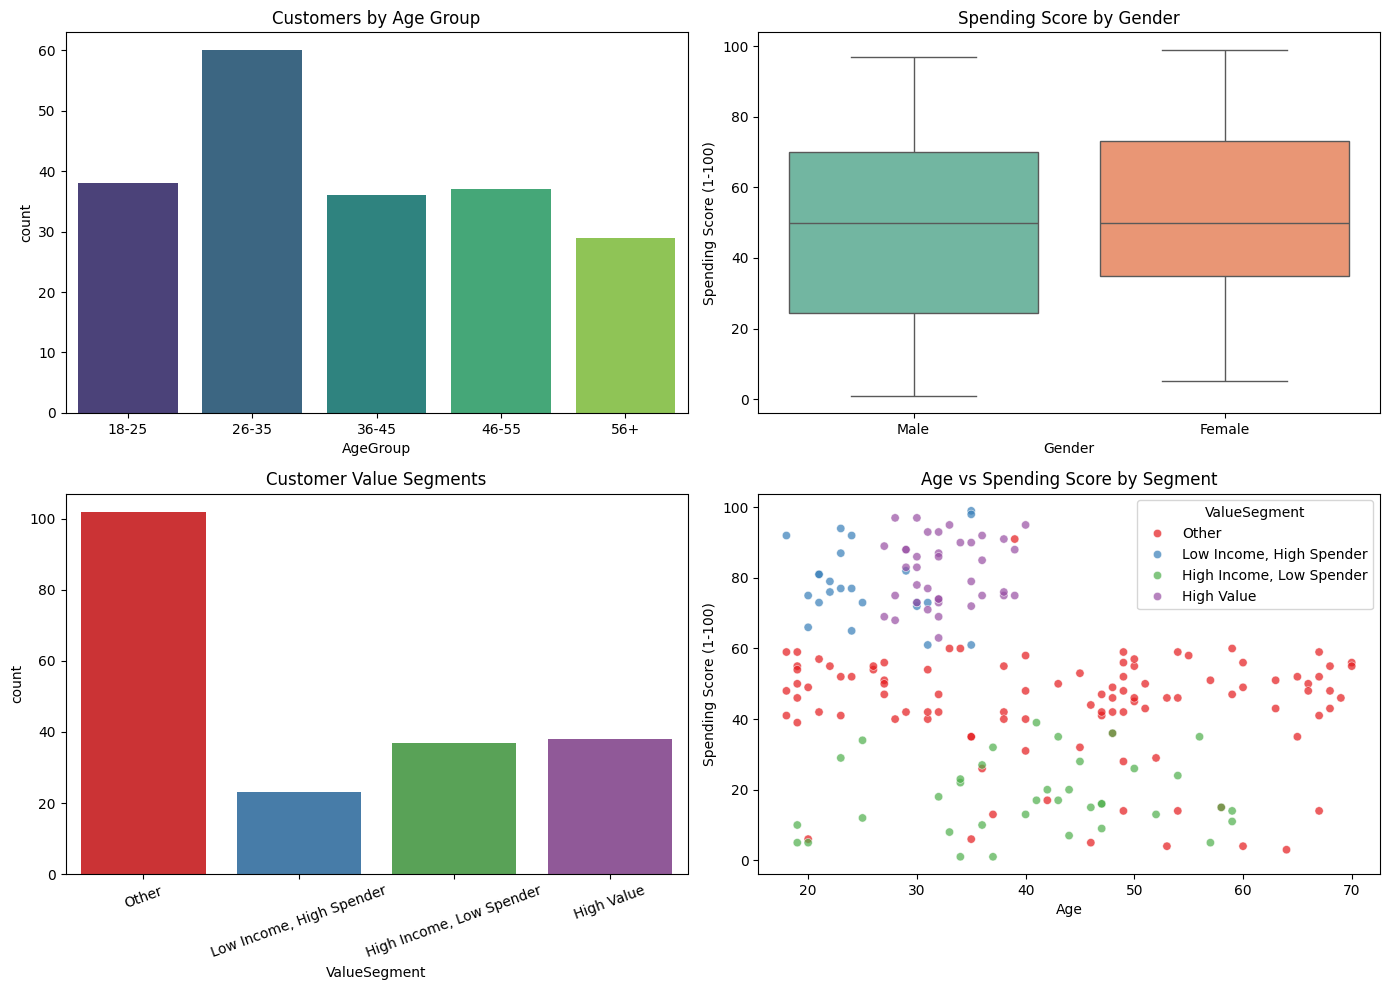

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='AgeGroup', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Customers by Age Group')

sns.boxplot(data=df, x='Gender', y='Spending Score (1-100)', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Spending Score by Gender')

sns.countplot(data=df, x='ValueSegment', ax=axes[1,0], palette='Set1')
axes[1,0].set_title('Customer Value Segments')
axes[1,0].tick_params(axis='x', rotation=20)

sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', hue='ValueSegment', ax=axes[1,1], palette='Set1', alpha=0.7)
axes[1,1].set_title('Age vs Spending Score by Segment')

plt.tight_layout()
plt.show()

# Key Findings & Marketing Strategy

## Customer Segments
- **High Value** (high income, high spending): ___ customers, average age ___, mostly ___.
- **High Income, Low Spender**: ___ customers — have money but aren't spending much here.
- **Low Income, High Spender**: ___ customers — loyal despite limited budget.

## Insights
- The 26-35 age group makes up the largest share of customers.
- Spending score does not differ much by gender.
- High-value customers cluster in a distinct region of the income/spending chart, separate from other groups.

## Recommended Marketing Strategies
1. **High Value customers:** offer loyalty perks and early access to new products to retain them, since they drive the most revenue.
2. **High Income, Low Spenders:** target with personalized offers or premium product highlights to convert their income into spending.
3. **Low Income, High Spenders:** reward their loyalty with discounts or a points system, since they already engage often despite budget limits.
4. **Age 26-35 group:** since they're the largest segment, tailor campaigns (social media ads, trend-driven products) toward this age range.